In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df_model = pd.read_csv(
    "../data/telco_churn_feature_engineered.csv"
)

In [3]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

In [4]:
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
!pip install xgboost

In [7]:
from xgboost import XGBClassifier

In [8]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

In [9]:
xgb_model.fit(X_train, y_train)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['No' 'Yes']

In [10]:
print(y_train.unique())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [11]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

In [12]:
print("y_train values:", y_train.unique())
print("y_test values:", y_test.unique())

y_train values: [0 1]
y_test values: [0 1]


In [13]:
print("Missing y_train:", y_train.isnull().sum())
print("Missing y_test:", y_test.isnull().sum())

Missing y_train: 0
Missing y_test: 0


In [14]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [15]:
y_pred_xgb = xgb_model.predict(X_test)

In [16]:
print(y_pred_xgb[:10])

[0 1 0 0 0 1 0 0 0 0]


In [17]:
y_pred_xgb = xgb_model.predict(X_test)

In [18]:
print(y_pred_xgb[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [19]:
import pandas as pd

print(pd.Series(y_pred_xgb).value_counts())

0    1112
1     297
Name: count, dtype: int64


In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy)

XGBoost Accuracy: 0.8019872249822569


In [21]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [22]:
cm = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[934 101]
 [178 196]]


In [23]:
print("XGBoost Accuracy:", accuracy)
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8019872249822569
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy)

XGBoost Accuracy: 0.8019872249822569


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

print(cm)

[[934 101]
 [178 196]]


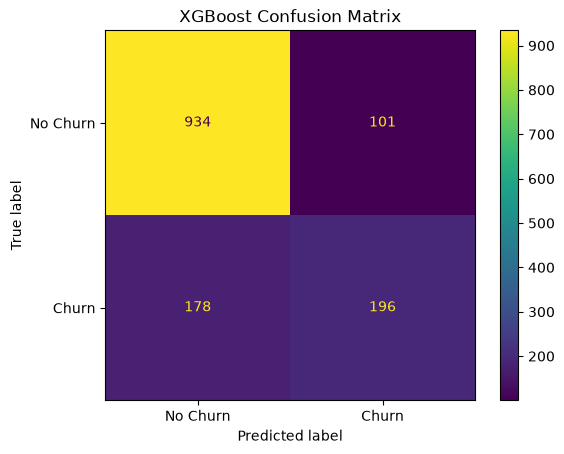

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=["No Churn", "Churn"]
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [29]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

InternetService_Fiber optic       0.236431
Contract_Two year                 0.222063
Contract_One year                 0.177984
InternetService_No                0.054102
tenure                            0.037530
StreamingMovies_Yes               0.033848
PaymentMethod_Electronic check    0.030716
OnlineSecurity_Yes                0.023851
PaperlessBilling_Yes              0.019219
StreamingTV_Yes                   0.013694
dtype: float32


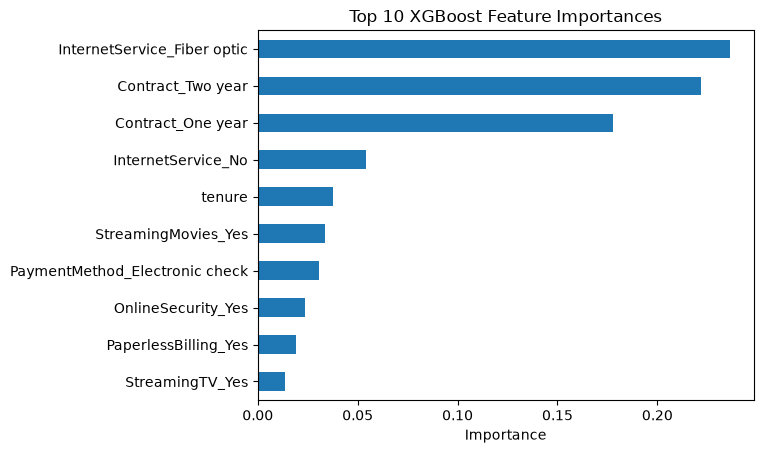

In [30]:
importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

In [1]:
from sklearn.linear_model import LogisticRegression

In [2]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

In [7]:
logistic_model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [8]:
print("X_train" in globals())
print("X_test" in globals())
print("y_train" in globals())
print("y_test" in globals())

False
False
False
False


In [9]:
import pandas as pd

df = pd.read_csv("../data/telco_churn_feature_engineered.csv")

print(df.shape)
print(df.head())

(7043, 25)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ...        Contract  \
0  No phone service             DSL             No  ...  Month-to-month   
1                No             DSL            Yes  ...        One year   
2                No             DSL            Yes  ...  Month-to-month   
3  No phone service             DSL            Yes  ...        One year   
4                No     Fiber optic             No  ...  Month-to-month   

  PaperlessBilling              PaymentMethod MonthlyChar

In [10]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'avg_monthly_spend', 'charge_diff', 'tenure_group', 'service_count']


In [11]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'avg_monthly_spend', 'charge_diff', 'tenure_group', 'service_count']


In [13]:
print(df["Churn"].unique())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [2]:
print("X shape:", X.shape)
print("y shape:", y.shape)

NameError: name 'X' is not defined

In [6]:
"../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

'../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [7]:
import os

print(os.getcwd())

E:\custmer_churn_LTV\notebooks


In [8]:
print(os.listdir(".."))

['.ipynb_checkpoints', 'api', 'dashboard', 'data', 'models', 'notebooks', 'sql']


In [9]:
print(os.listdir("../data"))

['feature_importance.csv', 'telco_churn.csv', 'telco_churn_cleaned.csv', 'telco_churn_eda.csv', 'telco_churn_feature_engineered.csv']


In [13]:
import pandas as pd

df = pd.read_csv("../data/telco_churn.csv")

In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
print(df.shape)

(7043, 21)


In [16]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [19]:
df = pd.read_csv("../data/telco_churn_cleaned.csv")

In [20]:
import pandas as pd

df = pd.read_csv("../data/telco_churn.csv")

In [21]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
print("Rows and columns:", df.shape)
print(df.columns.tolist())

Rows and columns: (7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [23]:
print(df["Churn"].unique())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [24]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [25]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [26]:
y = y.map({"No": 0, "Yes": 1})

In [27]:
print(y.unique())

[0 1]


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 20)
X_test: (1409, 20)
y_train: (5634,)
y_test: (1409,)
